# Lesson 5 — Multi-Agent System (Supervisor Pattern)

## What you will learn
- How to build **multiple specialized agents**
- The **Supervisor pattern** — one coordinator that delegates
- How agents **hand off** tasks to each other
- Combining everything from Lessons 1–4

## Architecture
```
User Question
     ↓
[SUPERVISOR]  ← reads conversation, decides who should act
     ├── math_agent    → does calculations, reports back
     ├── weather_agent → gets weather, reports back  
     ├── qa_agent      → answers knowledge questions, reports back
     └── FINISH        → done! return answer to user
```

## Why Multi-Agent?
- Each agent is an **expert** in its domain
- The supervisor **orchestrates** without doing the actual work
- This scales to **dozens of specialized agents**
- The pattern mirrors real-world teams: manager + specialists

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from config import get_ollama_model

from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
import json

## Step 1 — Define Specialist Tools

In [2]:
@tool
def calculate(expression: str) -> str:
    """Evaluate a math expression like '15 * 7 + 23'."""
    try:
        result = eval(expression, {"__builtins__": {}}, {})
        return f"{expression} = {result}"
    except Exception as e:
        return f"Error: {e}"


@tool
def get_weather(city: str) -> str:
    """Get weather for a city."""
    weather_db = {
        "london": "Cloudy, 15°C", "paris": "Sunny, 22°C",
        "new york": "Partly cloudy, 18°C", "cairo": "Hot, 35°C",
    }
    return weather_db.get(city.lower(), f"No data for {city}")


@tool
def answer_question(question: str) -> str:
    """Answer general knowledge questions."""
    knowledge = {
        "python": "Python is a high-level language created by Guido van Rossum in 1991.",
        "langgraph": "LangGraph builds stateful multi-actor LLM applications as graphs.",
        "langchain": "LangChain is a framework for LLM-powered applications.",
    }
    for key, fact in knowledge.items():
        if key in question.lower():
            return fact
    return f"No info found for: {question}"


print("Tools defined!")

Tools defined!


## Step 2 — State and LLMs

In [3]:
class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    next_agent: str    # supervisor writes this; router reads it


llm = ChatOllama(model=get_ollama_model(), temperature=0)

math_llm    = llm.bind_tools([calculate])
weather_llm = llm.bind_tools([get_weather])
qa_llm      = llm.bind_tools([answer_question])

print("State and LLMs ready!")

State and LLMs ready!


## Step 3 — The Supervisor Node

The supervisor is an LLM that **only decides routing** — it doesn't do the actual work.  
It outputs a JSON like `{"next": "math_agent"}` or `{"next": "FINISH"}`.

In [4]:
SUPERVISOR_SYSTEM = """You are a supervisor that routes tasks to specialist agents.

Available agents:
- math_agent: handles mathematical calculations
- weather_agent: handles weather queries  
- qa_agent: handles general knowledge questions

Respond ONLY with a JSON object:
{"next": "math_agent"} or {"next": "weather_agent"} or {"next": "qa_agent"} or {"next": "FINISH"}

Use FINISH when the question has been fully answered."""


def supervisor_node(state: MultiAgentState) -> dict:
    print("\n[supervisor] Routing...")
    messages = [SystemMessage(content=SUPERVISOR_SYSTEM)] + state["messages"]
    response = llm.invoke(messages)
    
    try:
        raw = response.content.strip()
        start, end = raw.find("{"), raw.rfind("}") + 1
        parsed = json.loads(raw[start:end])
        next_agent = parsed.get("next", "FINISH")
    except Exception:
        next_agent = "FINISH"
    
    print(f"[supervisor] → {next_agent}")
    return {"next_agent": next_agent}

## Step 4 — Specialist Agent Nodes

In [5]:
def run_specialist(bound_llm, tools_list, role_name: str, state: MultiAgentState) -> dict:
    print(f"\n[{role_name}] Working...")
    specialist_tools = ToolNode(tools_list)
    system = SystemMessage(content=f"You are the {role_name}. Use your tools to answer.")
    messages = [system] + state["messages"]

    for _ in range(3):  # max 3 iterations
        response = bound_llm.invoke(messages)
        messages.append(response)
        if not (hasattr(response, "tool_calls") and response.tool_calls):
            break
        tool_results = specialist_tools.invoke({"messages": messages})
        messages.extend(tool_results["messages"])

    new_messages = messages[len(state["messages"]) + 1:]
    print(f"[{role_name}] Done, reporting back to supervisor.")
    return {"messages": new_messages}


def math_agent_node(state):    return run_specialist(math_llm,    [calculate],       "math_agent",    state)
def weather_agent_node(state): return run_specialist(weather_llm, [get_weather],     "weather_agent", state)
def qa_agent_node(state):      return run_specialist(qa_llm,      [answer_question], "qa_agent",      state)

print("Specialist nodes defined!")

Specialist nodes defined!


## Step 5 — Build and Compile the Graph

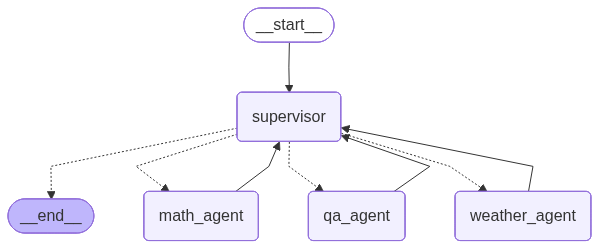

In [6]:
def route_after_supervisor(state: MultiAgentState) -> str:
    next_agent = state.get("next_agent", "FINISH")
    return next_agent if next_agent in ["math_agent", "weather_agent", "qa_agent"] else "__end__"


graph_builder = StateGraph(MultiAgentState)

graph_builder.add_node("supervisor",     supervisor_node)
graph_builder.add_node("math_agent",     math_agent_node)
graph_builder.add_node("weather_agent",  weather_agent_node)
graph_builder.add_node("qa_agent",       qa_agent_node)

graph_builder.add_edge(START, "supervisor")

graph_builder.add_conditional_edges(
    "supervisor",
    route_after_supervisor,
    {
        "math_agent":    "math_agent",
        "weather_agent": "weather_agent",
        "qa_agent":      "qa_agent",
        "__end__":       END,
    }
)

# All specialists report back to supervisor
graph_builder.add_edge("math_agent",    "supervisor")
graph_builder.add_edge("weather_agent", "supervisor")
graph_builder.add_edge("qa_agent",      "supervisor")

graph = graph_builder.compile()

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph compiled! (visualization: {e})")

## Step 6 — Test the Multi-Agent System

In [7]:
def ask(question: str) -> str:
    print(f"\n{'='*55}")
    print(f"User: {question}")
    print('='*55)
    result = graph.invoke({
        "messages": [HumanMessage(content=question)],
        "next_agent": ""
    })
    answer = result["messages"][-1].content
    print(f"\nAnswer: {answer}")
    return answer

# Test math agent
ask("What is 144 divided by 12?")


User: What is 144 divided by 12?

[supervisor] Routing...
[supervisor] → math_agent

[math_agent] Working...
[math_agent] Done, reporting back to supervisor.

[supervisor] Routing...
[supervisor] → math_agent

[math_agent] Working...
[math_agent] Done, reporting back to supervisor.

[supervisor] Routing...
[supervisor] → math_agent

[math_agent] Working...
[math_agent] Done, reporting back to supervisor.

[supervisor] Routing...
[supervisor] → math_agent

[math_agent] Working...
[math_agent] Done, reporting back to supervisor.

[supervisor] Routing...
[supervisor] → FINISH

Answer:  So, the answer is 12.
</think>

The result of dividing 144 by 12 is 12.


' So, the answer is 12.\n</think>\n\nThe result of dividing 144 by 12 is 12.'

In [8]:
# Test weather agent
ask("What is the weather in Cairo?")


User: What is the weather in Cairo?

[supervisor] Routing...
[supervisor] → weather_agent

[weather_agent] Working...
[weather_agent] Done, reporting back to supervisor.

[supervisor] Routing...
[supervisor] → weather_agent

[weather_agent] Working...
[weather_agent] Done, reporting back to supervisor.

[supervisor] Routing...
[supervisor] → weather_agent

[weather_agent] Working...
[weather_agent] Done, reporting back to supervisor.

[supervisor] Routing...
[supervisor] → math_agent

[math_agent] Working...
[math_agent] Done, reporting back to supervisor.

[supervisor] Routing...
[supervisor] → FINISH

Answer:  

If you have any more questions, feel free to ask! 😊
</think>

The weather in Cairo is hot with a temperature of 35°C.


' \n\nIf you have any more questions, feel free to ask! 😊\n</think>\n\nThe weather in Cairo is hot with a temperature of 35°C.'

In [ ]:
# Test QA agent
ask("Tell me about LangGraph.")

## Key Takeaways

| Concept | Description |
|---------|-------------|
| Supervisor pattern | One coordinator LLM routes to specialist agents |
| `next_agent` state field | Supervisor writes, router reads |
| Specialist reports back | `specialist → supervisor` edge creates the cycle |
| `FINISH` | Supervisor decides when the task is fully done |
| Scalability | Add more specialists without changing the core loop |

## 🏋️ Final Exercise — Add a Code Agent
1. Create a `@tool` called `explain_python_code` that takes a snippet and returns an explanation
2. Create a `code_agent_node` specialist
3. Add `code_agent` to the supervisor's system prompt and routing
4. Ask: `"Explain this: [x**2 for x in range(10)]"`

## Congratulations! 🎉
You've completed the full LangGraph curriculum:
- ✅ Lesson 1: StateGraph, nodes, edges
- ✅ Lesson 2: Conditional edges and branching
- ✅ Lesson 3: Chatbot with memory
- ✅ Lesson 4: ReAct agent with tools
- ✅ Lesson 5: Multi-agent supervisor system

In [ ]:
# Your code agent exercise here
